# 09 · Unannotated-record Recovery

**Purpose.** Validate the tool's *core reason to exist*: assigning annotation to records that have **no** (or non-useful) annotation. Units 03/04 prove *coordinate transfer is correct when the query already carries truth*; this notebook proves the tool can **recover that annotation when it is absent**.

Two complementary tests:
1. **Strip test** — take annotated records, delete their features, re-annotate via tblastn lifting, and score against the original annotation (which serves as truth).
2. **Real noAnno records** — run directly on `FMD_OQ211398_noAnno.gb` and `PRRS_PP946131_noAnno.gb` to demonstrate end-to-end annotation on genuinely unannotated input.

## Inputs

Annotated query sets (as truth source) + reference; plus the two real noAnno GenBank files.

In [1]:
from pathlib import Path
from copy import deepcopy
import sys, time

import pandas as pd
import matplotlib.pyplot as plt

# --- anchor ROOT to the repo (folder that contains app/src) ---
ROOT = Path.cwd()
for candidate in [ROOT, *ROOT.parents]:
    if (candidate / "app" / "src").exists():
        ROOT = candidate
        break
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

DATA = ROOT / "app" / "data"

FMD_REF    = DATA / "FMD"  / "FMD_ref_test.gb"
FMD_QUERY  = DATA / "FMD"  / "FMD_100seq_anno.gb"
PRRS_REF   = DATA / "PRRS" / "PRRS_ref_test.gb"
PRRS_QUERY = DATA / "PRRS" / "PRRS_100seq_anno.gb"
PED_REF    = DATA / "PED"  / "PED_ref_1.gb"
PED_QUERY  = DATA / "PED"  / "PED_100seqs.gb"

# real unannotated records already in the repo:
FMD_NOANNO  = DATA / "FMD"  / "FMD_OQ211398_noAnno.gb"
PRRS_NOANNO = DATA / "PRRS" / "PRRS_PP946131_noAnno.gb"

RUN_FULL = True     # paper numbers: all 100 records per virus
SAMPLE_N = 10

In [2]:
UNIT_DIR = ROOT / "app" / "validation" / "09_recovery_unannotated"
OUT = UNIT_DIR / "outputs"
OUT.mkdir(parents=True, exist_ok=True)
print("outputs ->", OUT)

outputs -> /root/work/app/validation/09_recovery_unannotated/outputs


## Setup — modules

In [3]:
from app.src.io.genbank_parser import load_genbank_records, load_single_genbank
from app.src.features.annotation_strategy import get_strategy
from app.src.lifting.tblastn_lifter import lift_all_tblastn
from app.src.pipeline import PipelineConfig
from app.validation._shared.validation_utils import (
    load_reference_bundle, lifted_to_rows, compare_predictions_to_truth,
    parse_truth_features, dedupe_truth_by_name, ref_codon_checkable_genes,
)

CFG = PipelineConfig()   # production defaults, same as the accuracy harness

def strip_annotation(record):
    """Deep copy of the record with every feature removed; sequence untouched.

    This is what makes the test leakage-free: the tool is handed a record that is
    indistinguishable from a genuinely unannotated GenBank submission, while the original
    annotation is held back and used only by the scorer.
    """
    bare = deepcopy(record)
    bare.features = []
    return bare

## Test 1 — Strip test (annotate → strip → re-lift → compare)

For each record the original (alias-normalised) annotation is kept as **truth**, the tool is handed
a de-annotated copy, and we check both halves of the claim:

- **(a) routing** — the router must send the stripped record to `tblastn`, and the *same record with
  its annotation intact* must go to `direct`. Both directions are asserted, so the test proves the
  router reacts to annotation rather than always picking one branch.
- **(b) recovery** — the lifted coordinates must match the withheld truth.

**Scoring follows the standalone-accuracy convention** (`VALIDATION_METHODOLOGY.md` §6, row 1), not
the cross-tool one: truth-anchored denominator `R ∩ truth`, IoU >= 0.90 or ±6 bp, and the per-gene
codon exemption via `ref_codon_checkable_genes` (so PRRSV ORF1b, a −1 frameshift gene with no ATG,
is not failed for biology). Numbers here are therefore comparable with `02_lifting_accuracy`, and
the difference between the two is exactly what stripping the annotation costs.

In [4]:
DATASETS = {"fmd": (FMD_REF, FMD_QUERY), "prrs": (PRRS_REF, PRRS_QUERY), "ped": (PED_REF, PED_QUERY)}

rows, cov, routing = [], [], []
for label, (ref_path, query_path) in DATASETS.items():
    bundle = load_reference_bundle(ref_path)
    ref_names = sorted({f["name"] for f in bundle["features"]})      # evaluable set R
    codon_required = ref_codon_checkable_genes(bundle)
    ftype = bundle["feature_type"]
    records = load_genbank_records(query_path)
    records = records if RUN_FULL else records[:SAMPLE_N]
    for rec in records:
        # truth = the record's own annotation, alias-normalised, restricted to R (same as 02)
        truth, _ = parse_truth_features(rec, bundle["alias_lookup"], ftype,
                                        filter_nested=False, target_names=ref_names,
                                        keep_extra_names=[])
        truth = dedupe_truth_by_name(truth)
        if not truth:
            continue

        bare = strip_annotation(rec)
        # allowed_types mirrors run_pipeline: the reference defines the working level
        strat_bare, _ = get_strategy(bare, bundle["alias_lookup"], allowed_types=(ftype,) if ftype else None)
        strat_anno, _ = get_strategy(rec,  bundle["alias_lookup"], allowed_types=(ftype,) if ftype else None)
        routing.append({"virus": label, "record_id": rec.id,
                        "stripped_routed_to": strat_bare, "annotated_routed_to": strat_anno})

        lifted = lift_all_tblastn(
            ref_features=bundle["features"], ref_record=bundle["record"], query_record=bare,
            min_coverage=CFG.min_coverage, min_identity=CFG.min_identity,
            evalue=CFG.evalue, rescue_window=CFG.rescue_window,
            validate_codons=(ftype == "CDS"),
        )
        preds = lifted_to_rows(rec.id, lifted, "tblastn")
        compared = compare_predictions_to_truth(preds, truth, codon_required_names=codon_required)
        compared.insert(0, "virus", label)
        compared["routed_to"] = strat_bare
        rows.append(compared)

        # truth-anchored coverage: one row per truth gene
        ok = set(compared.loc[compared["coord_correct"], "pred_name"])
        ex = set(compared.loc[compared["exact_match"], "pred_name"])
        cov += [{"virus": label, "record_id": rec.id, "gene": t["name"],
                 "found": t["name"] in ok, "exact": t["name"] in ex} for t in truth]

strip_df = pd.concat(rows, ignore_index=True)
strip_df.to_csv(OUT / "strip_recovery_per_prediction.tsv", sep="\t", index=False)
cov_df = pd.DataFrame(cov); cov_df.to_csv(OUT / "strip_recovery_coverage.tsv", sep="\t", index=False)
route_df = pd.DataFrame(routing); route_df.to_csv(OUT / "routing_audit.tsv", sep="\t", index=False)

print("ROUTING AUDIT")
print("  stripped  ->", route_df["stripped_routed_to"].value_counts().to_dict())
print("  annotated ->", route_df["annotated_routed_to"].value_counts().to_dict())
assert set(route_df["stripped_routed_to"]) == {"tblastn"}, "a stripped record was NOT routed to tblastn"
print(f"\n{len(route_df)} records, {len(cov_df)} truth genes recovered-and-scored")
strip_df.head()

ROUTING AUDIT
  stripped  -> {'tblastn': 296}
  annotated -> {'direct': 296}

296 records, 2473 truth genes recovered-and-scored


,virus,record_id,method,ref_name,pred_name,source_name,pred_start,pred_end,strand,status,...,within_bp_tolerance,coord_correct,exact_match,pred_len,truth_len,pred_minus_truth_len,delta_start,delta_end,failure_mode,routed_to
0,fmd,AY687333.1,tblastn,Lpro,Lpro,None,1082,1684,+,ok,...,True,True,True,603,603.0,0.0,0.0,0.0,Correct,tblastn
1,fmd,AY687333.1,tblastn,VP4,VP4,None,1685,1939,+,ok,...,True,True,True,255,255.0,0.0,0.0,0.0,Correct,tblastn
2,fmd,AY687333.1,tblastn,VP2,VP2,None,1940,2593,+,ok,...,True,True,True,654,654.0,0.0,0.0,0.0,Correct,tblastn
3,fmd,AY687333.1,tblastn,VP3,VP3,None,2594,3250,+,ok,...,True,True,True,657,657.0,0.0,0.0,0.0,Correct,tblastn
4,fmd,AY687333.1,tblastn,VP1,VP1,None,3251,3880,+,ok,...,True,True,False,630,636.0,-6.0,0.0,-6.0,Boundary offset,tblastn


## Metrics — recovery accuracy on de-annotated records

In [5]:
# Truth-anchored recovery accuracy: exact / coord_only / failed, per virus
b = cov_df.assign(bucket=lambda d: d.apply(
        lambda r: "exact" if r["exact"] else ("coord_only" if r["found"] else "failed"), axis=1))
recovery = (b.pivot_table(index="virus", columns="bucket", values="gene", aggfunc="size", fill_value=0)
              .reindex(columns=["exact", "coord_only", "failed"], fill_value=0))
recovery["total"] = recovery.sum(axis=1)
recovery["exact_pct"] = (recovery["exact"] / recovery["total"] * 100).round(2)
recovery["accuracy_pct"] = ((recovery["exact"] + recovery["coord_only"]) / recovery["total"] * 100).round(2)
recovery = recovery.reset_index()
recovery.to_csv(OUT / "strip_recovery_accuracy.tsv", sep="\t", index=False)
print(recovery.to_string(index=False))

per_gene = (cov_df.groupby(["virus", "gene"])["found"].agg(["size", "sum"])
              .assign(pct=lambda d: (d["sum"] / d["size"] * 100).round(1)))
per_gene.to_csv(OUT / "strip_recovery_per_gene.tsv", sep="\t")
per_gene

virus  exact  coord_only  failed  total  exact_pct  accuracy_pct
  fmd   1138          32       2   1172      97.10         99.83
  ped    500           4       1    505      99.01         99.80
 prrs    706          88       2    796      88.69         99.75


size  sum    pct
virus gene                   
fmd   2A       98   98  100.0
      2B       98   98  100.0
      2C       98   98  100.0
      3A       98   97   99.0
      3B       96   96  100.0
      3Cpro    98   98  100.0
      3Dpol    98   98  100.0
      Lpro     98   98  100.0
      VP1      97   97  100.0
      VP2      98   97   99.0
      VP3      97   97  100.0
      VP4      98   98  100.0
ped   E        97   97  100.0
      M        97   97  100.0
      N        97   97  100.0
      ORF1a    17   17  100.0
      ORF1b     8    7   87.5
      ORF3     92   92  100.0
      S        97   97  100.0
prrs  ORF1a    62   62  100.0
      ORF1b    88   87   98.9
      ORF2a   100  100  100.0
      ORF2b    49   48   98.0
      ORF3    100  100  100.0
      ORF4    100  100  100.0
      ORF5     99   99  100.0
      ORF6     99   99  100.0
      ORF7     99   99  100.0

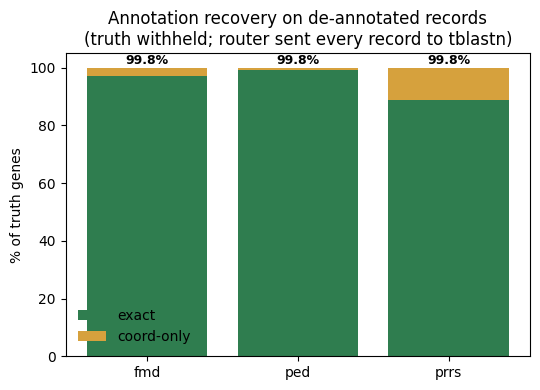

In [6]:
fig, ax = plt.subplots(figsize=(5.5, 4))
ax.bar(recovery["virus"], recovery["exact_pct"], label="exact", color="#2f7d4f")
ax.bar(recovery["virus"], recovery["accuracy_pct"] - recovery["exact_pct"],
       bottom=recovery["exact_pct"], label="coord-only", color="#d6a13d")
ax.set_ylabel("% of truth genes"); ax.set_ylim(0, 105); ax.legend(frameon=False)
ax.set_title("Annotation recovery on de-annotated records\n(truth withheld; router sent every record to tblastn)")
for i, r in recovery.iterrows():
    ax.text(i, r["accuracy_pct"] + 1.5, f'{r["accuracy_pct"]:.1f}%', ha="center", fontsize=9, fontweight="bold")
fig.tight_layout(); fig.savefig(OUT / "strip_recovery_accuracy.png", dpi=200, bbox_inches="tight")

## Test 2 — Real unannotated GenBank records

Run the tool on the two genuinely unannotated files. There is no per-record truth here, so this is a **demonstration**: confirm routing = tblastn and that the tool emits a plausible gene table (names, coordinates, coverage, identity).

In [7]:
noanno = {"fmd": (FMD_REF, FMD_NOANNO), "prrs": (PRRS_REF, PRRS_NOANNO)}
demo_rows = []
for label, (ref_path, q_path) in noanno.items():
    bundle = load_reference_bundle(ref_path)
    ftype = bundle["feature_type"]
    rec = load_single_genbank(q_path)
    strategy, _ = get_strategy(rec, bundle["alias_lookup"], allowed_types=(ftype,) if ftype else None)
    t0 = time.perf_counter()
    lifted = lift_all_tblastn(
        ref_features=bundle["features"], ref_record=bundle["record"], query_record=rec,
        min_coverage=CFG.min_coverage, min_identity=CFG.min_identity,
        evalue=CFG.evalue, rescue_window=CFG.rescue_window,
        validate_codons=(ftype == "CDS"),
    )
    elapsed = time.perf_counter() - t0
    n_ref = len({f['name'] for f in bundle['features']})
    got = [r for r in lifted_to_rows(rec.id, lifted, "tblastn") if r.get("pred_start")]
    print(f"{label}: {rec.id}  routed_to={strategy}  len={len(rec.seq)}  "
          f"annotated {len(got)}/{n_ref} reference genes in {elapsed:.1f}s")
    for r in lifted_to_rows(rec.id, lifted, "tblastn"):
        r["virus"] = label; demo_rows.append(r)

demo_df = pd.DataFrame(demo_rows)
demo_df.to_csv(OUT / "noanno_demo_predictions.tsv", sep="\t", index=False)
demo_df[["virus", "record_id", "pred_name", "pred_start", "pred_end", "strand",
         "coverage", "identity", "status"]]

fmd: OQ211398.1  routed_to=tblastn  len=8274  annotated 12/12 reference genes in 0.1s
prrs: PP946131.1  routed_to=tblastn  len=16932  annotated 9/9 reference genes in 0.1s


/usr/local/lib/python3.11/dist-packages/Bio/GenBank/Scanner.py:1215: BiopythonParserWarning: Premature end of file in sequence data
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/Bio/GenBank/Scanner.py:1215: BiopythonParserWarning: Premature end of file in sequence data
  warnings.warn(


,virus,record_id,pred_name,pred_start,pred_end,strand,coverage,identity,status
0,fmd,OQ211398.1,Lpro,1173,1775,+,1.0000,99.0,ok
1,fmd,OQ211398.1,VP4,1776,2030,+,1.0000,100.0,ok
2,fmd,OQ211398.1,VP2,2031,2684,+,1.0000,100.0,ok
3,fmd,OQ211398.1,VP3,2685,3344,+,1.0000,100.0,ok
4,fmd,OQ211398.1,VP1,3345,3977,+,1.0000,99.5,ok
5,fmd,OQ211398.1,2A,3978,4031,+,1.0000,94.4,ok
6,fmd,OQ211398.1,2B,4032,4493,+,1.0000,99.4,ok
7,fmd,OQ211398.1,2C,4494,5447,+,1.0000,99.7,ok
8,fmd,OQ211398.1,3A,5448,5906,+,1.0000,96.1,ok
9,fmd,OQ211398.1,3B,5907,6119,+,1.0000,100.0,ok


## Interpretation

> Fill in after the run. This unit is the direct evidence for **approach 2 in the project brief**
> ("assign annotation to gene segments that have none"), which the coordinate-transfer units do not
> cover: they all score records that already carried truth.
>
> Two claims to state separately:
> 1. **Routing works both ways** — every stripped record went to `tblastn`, and the same records with
>    annotation intact went to `direct`. Without the second half, the router could simply be
>    hard-wired to lift.
> 2. **Recovery accuracy** — compare against `02_lifting_accuracy` on the same records. The two use
>    the same metric and the same codon policy, so any difference is the cost of losing the
>    annotation, not a scoring change.